# Data preprocessing

The dataset used in this project is the **Spam, Ham and Phishing Message Dataset for NLP** available on Kaggle:
https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset

It contains ~515k messages labelled as ham (0), spam (1), or phishing (2). The data is already quite clean from the source, but we still want to inspect it, standardise the format, and remove any nulls or duplicates before doing any analysis.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = ".."  # project root

## Load and clean

In [20]:
pd.set_option("display.max_colwidth", 80)

df = pd.read_csv(f"{BASE}/data/raw/final_dataset.csv")
print(df.shape)
df.head(10)

(515345, 2)


,label,text
0,0,annual physical scheduled 5 jun 2025 1015 location chicago
1,0,please save e mail records dear craig congratulations becoming cheap tickets...
2,1,need urgent assistance donald williams esq 60 cannon street london ec 4 n 6 ...
3,2,megasize unit megadlk huge advancement mens health benefits escapenumber inc...
4,0,original message rodenburg eric enron sent monday january escapenumber escap...
5,0,wondered laptops found work well dmdx inspiron escapenumber dell longer make...
6,0,sbi account xxxx1234 credited rs 25500 17 jul 2025
7,0,jeanie highlight accomplishments first six months 2001 participated identify...
8,1,flipkart account lucky prize rs 48500 claim within 24 hours httprebrandly7ll6q9
9,0,swiggy order delivery track httpprizeportalino8ntoo


In [21]:
# standardise: numeric labels → strings, rename text → message
label_map = {0: "ham", 1: "spam", 2: "phishing"}
df = df.rename(columns={"text": "message"})
df["label"] = df["label"].map(label_map)
df = df[["label", "message"]]

In [22]:
n_before = len(df)
print(f"nulls:\n{df.isnull().sum()}")
print(f"\nduplicates: {df.duplicated(subset='message').sum()}")

df = df.dropna(subset=["message"])
df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)

print(f"\nrows: {n_before} → {len(df)}  (removed {n_before - len(df)})")

nulls:
label      0
message    0
dtype: int64

duplicates: 5961

rows: 515345 → 509384  (removed 5961)


## Class distribution

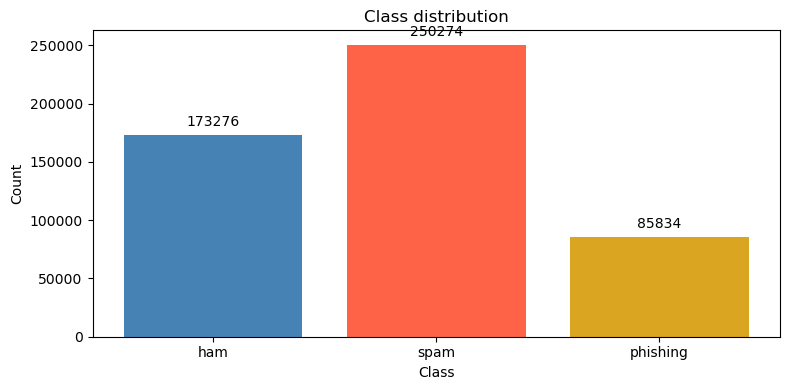

In [23]:
colors = ["steelblue", "tomato", "goldenrod"]
counts = df["label"].value_counts().reindex(["ham", "spam", "phishing"])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class distribution")
plt.tight_layout()
os.makedirs(f"{BASE}/reports/figures", exist_ok=True)
plt.savefig(f"{BASE}/reports/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
print((counts / counts.sum() * 100).round(1).to_string())

label
ham         34.0
spam        49.1
phishing    16.9


The dataset is moderately imbalanced — spam makes up around half of all messages while phishing is the smallest class. This matters for model evaluation: accuracy alone can be misleading when classes are unequal, so we'll rely on macro F1-score as the main metric throughout the project.

## Message length

In [25]:
df["msg_len"] = df["message"].str.len()
print(df.groupby("label")["msg_len"].describe().round(1))

             count    mean      std  min    25%    50%     75%         max
label                                                                     
ham       173276.0  1161.5  29535.9  6.0   54.0  223.0   958.0  11510306.0
phishing   85834.0  1176.1   2064.4  6.0  273.0  552.0  1289.0     91353.0
spam      250274.0   237.2   8774.3  6.0   63.0   72.0    82.0   4276922.0


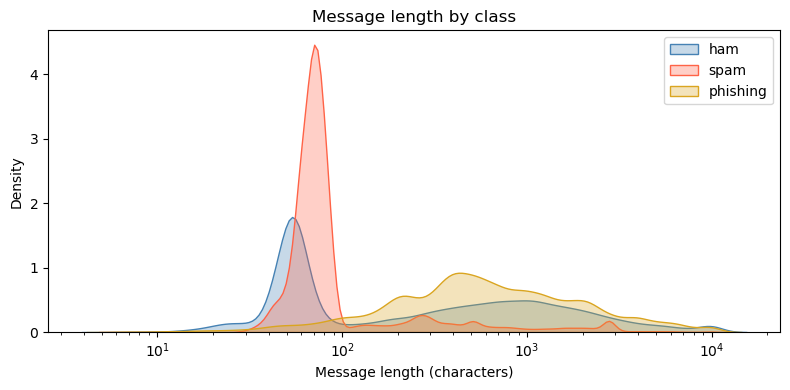

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip(["ham", "spam", "phishing"], colors):
    subset = df.loc[df["label"] == label, "msg_len"].clip(lower=1, upper=10_000)
    sns.kdeplot(subset, ax=ax, label=label, color=color,
                fill=True, alpha=0.3, log_scale=True)

ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Density")
ax.set_title("Message length by class")
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE}/reports/figures/message_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Save

In [27]:
out = df[["label", "message"]]

os.makedirs(f"{BASE}/data/processed", exist_ok=True)
out.to_csv(f"{BASE}/data/processed/cleaned_messages.csv", index=False)

print(f"saved cleaned_messages.csv  ({len(out)} rows)")

saved cleaned_messages.csv  (509384 rows)
